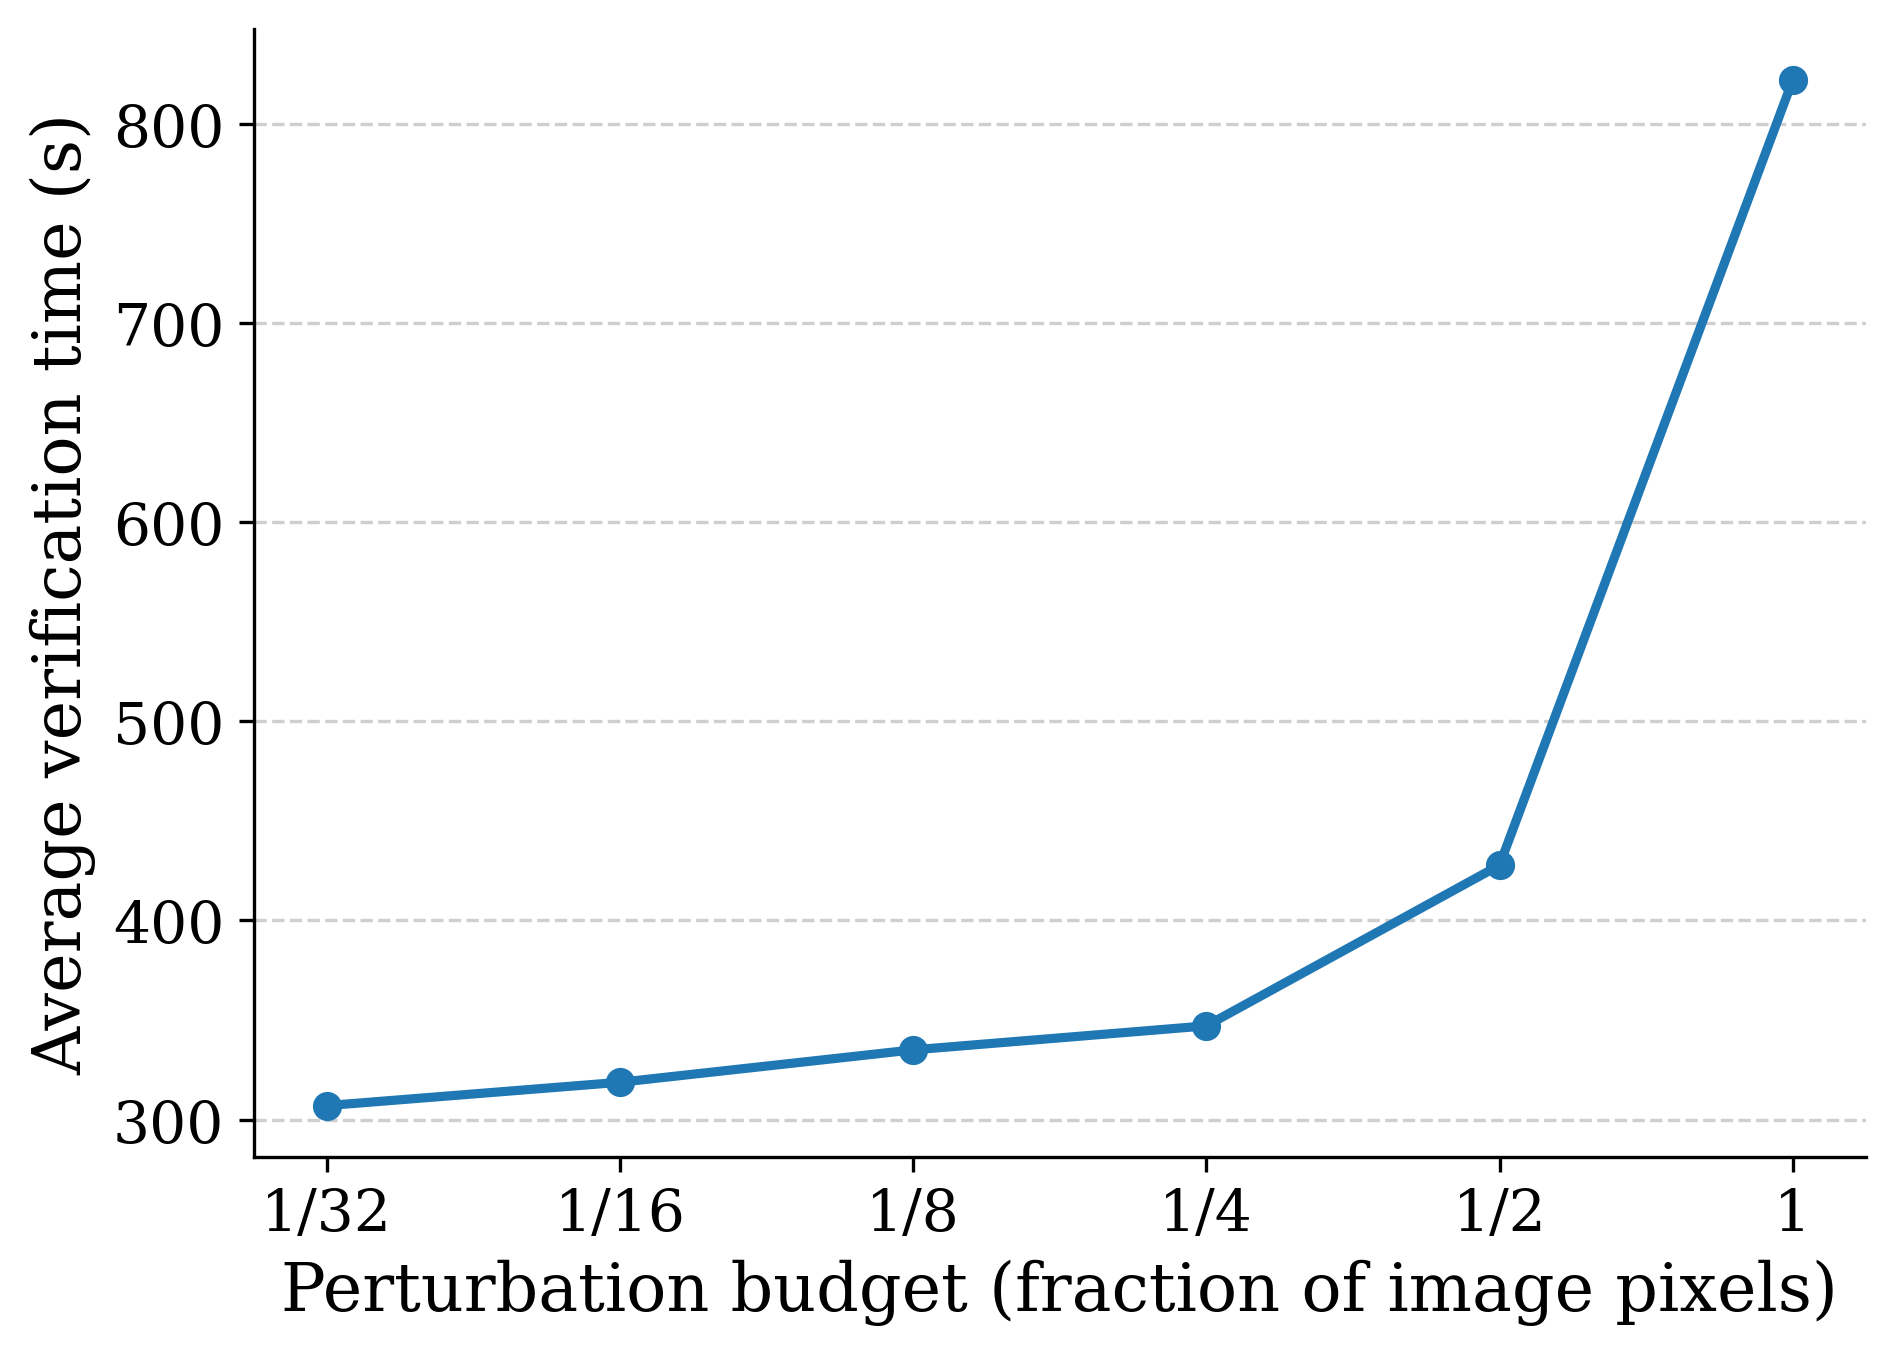

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================
# CONFIG
# ============================
CSV_PATH = "../../results/vggnet16/ALL_vggnet.csv"
OUT_PDF  = "Average_verification_time_paper.pdf"

# Match the SAME look you used before (serif + bigger text, no LaTeX needed)
BASE_FONTSIZE = 16  # tune (14/16/18) to match your paper
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE - 2,
    "ytick.labelsize": BASE_FONTSIZE - 2,
    "pdf.fonttype": 42,      # embed TrueType fonts in PDF (better for papers)
    "ps.fonttype": 42,
})

# ============================
# LOAD
# ============================
df = pd.read_csv(CSV_PATH)

# numeric safety
df["k"] = pd.to_numeric(df["k"], errors="coerce")
df["all_time"] = pd.to_numeric(df["all_time"], errors="coerce")

# k values: smallest -> full image
pixel_vals = np.array([
    1568,    # 1/32
    3136,    # 1/16
    6272,    # 1/8
    12544,   # 1/4
    25088,   # 1/2
    50176,   # 1
])

# Filter + aggregate
d = df[df["k"].isin(pixel_vals)].dropna(subset=["all_time"]).copy()

avg_time = (
    d.groupby("k")["all_time"]
     .mean()
     .reindex(pixel_vals)   # keep exact order
     .values
)

# x-axis labels
x_labels = ["1/32", "1/16", "1/8", "1/4", "1/2", "1"]
x_pos = np.arange(len(pixel_vals))

# ============================
# PLOT (paper-suited)
# ============================
fig, ax = plt.subplots(figsize=(6.6, 4.8), dpi=300)

ax.plot(
    x_pos,
    avg_time,
    marker="o",
    linewidth=2.2,
    markersize=6,
)

ax.set_xticks(x_pos, x_labels)
ax.set_xlabel("Perturbation budget (fraction of image pixels)")
ax.set_ylabel("Average verification time (s)")

# Paper-style grid + clean spines
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional: if you want a title, keep it small (papers often avoid big titles inside plots)
# ax.set_title("Effect of pixel perturbation on verification time", pad=6, fontweight="bold")

fig.tight_layout()
fig.savefig(OUT_PDF, format="pdf", bbox_inches="tight")
plt.show()